## Start-up example using composite_tools.py

In this notebook, we load the module `composite_tools.py` and use the functions therein to compute the complex moduli of the dilute spherical and dilute platelet composites.

** In this version, there are additional examples with less documentation. **

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import composite_tools

## Elastic endmember

First, let's consider an elastic composite with phase $1$ as the matrix and phase $2$ as the dilute inclusion.

In [22]:
# Bulk moduli (Pa)
K1 = 10e9
K2 = 30e9
# Shear moduli (Pa)
G1 = 1e9
G2 = 10e9

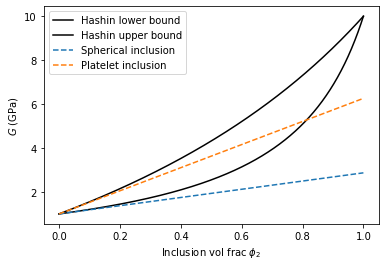

In [23]:
phi_range = np.linspace(0, 1, 1000)
Gmin, Gmax = composite_tools.G_Hashin_bounds(K1, K2, G1, G2, phi_range)

plt.plot(phi_range, Gmin / 1e9, 'k', label="Hashin lower bound")
plt.plot(phi_range, Gmax / 1e9, 'k', label="Hashin upper bound")
plt.plot(phi_range,
         composite_tools.SphericalInclusion.G(K1, G1, G2, phi_range) / 1e9,
         '--', label="Spherical inclusion")
plt.plot(phi_range,
         composite_tools.PlateletInclusion.G(K2, G1, G2, phi_range) / 1e9,
         '--', label="Platelet inclusion")

plt.xlabel(r"Inclusion vol frac $\phi_2$")
plt.ylabel(r"$G$ (GPa)")
plt.legend()

In the purely elastic case, the Hashin bounds are rigorous upper and lower bounds on the isotropic composite's elastic moduli. The composites formed by a dilute inclusion of spheres of phase $2$ or randomly oriented platelets of phase $2$ are shown superimposed on the Hashin bounds. The dilute composite moduli change linearly in the inclusion volume fraction $\phi_2$.

## Viscoelastic composites

Recognizing that for linear viscoelastic materials, a complex modulus can be used to express the viscoelastic response of the composite, we take the dilute composite formulae used above and substitute in complex moduli for phases $1$ and $2$.

Below, we provide an example of a composite viscoelastic material consisting of a dilute suspension of spherical inclusions. We select a viscoelastic matrix with shear viscosity $\eta_1$ and elastic moduli $K_1$, $G_1$. The composite bulk modulus depends also on the inclusion bulk modulus $K_2$, while the composite shear modulus depends also on the inclusion shear modulus $G_2$.

For an elastic material, the modulus is a scalar quantity. For a viscoelastic material, the complex modulus is a function of frequency; computationally, this is represented either as a callable function of frequency, or a vector of complex numbers corresponding to a discrete sample of frequencies.

In the following, we show three methods for evaluating the complex **bulk** modulus of the composite for discrete frequency samples given by `freq_vec`.

In [31]:
freq_vec = np.geomspace(1e-8, 1e1, 100)
phi2 = 0.05
eta1 = 1e14

#### Method (1/3) Plug complex shear modulus into composite formula
Use the composite formula for bulk modulus
  `K = K(K1, K2, G1, phi2)`
and plug in complex `G1` corresponding to a Maxwell material for a phase 1.

The function `mod2complex(De, G)` computes the complex shear modulus for a Maxwell material over a vector of Deborah numbers `De`. Here the Deborah number is defined with respect to the viscoelastic properties of phase $1$ only.

In [32]:
K_sweep = composite_tools.SphericalInclusion.K(K1, K2,
  composite_tools.MaxwellMaterial.mod2complex(freq_vec * eta1 / G1, G1), phi2)

#### Method (2/3) Composite bulk modulus as a mechanical circuit
By combining the two functions in Method 1, we can treat the composite bulk modulus as one big function of the frequency vector.

The function `K_complex(K1, K2, G1, eta1, phi2, freq_vec)` computes the complex shear modulus for the composite directly, given a vector of sample frequencies. Internally, the function computes the standard linear solid components corresponding to the composite, and uses these components to compute the complex bulk modulus as a function of the sample frequencies. For the parameters corresponding to each circuit component, see the source code for function `K_complex`.

In [33]:
K_complex_SLS = composite_tools.SphericalInclusion.K_complex(K1, K2, G1, eta1, phi2, freq_vec)

#### Method (3/3) Compute bulk modulus from pole-zero form
The composite bulk modulus can be represented as a rational function of frequency of the form
$$
K(i \omega) = A \frac{i\omega - z}{i\omega - p},
$$
where $A$ is the effective elastic modulus (apparent when $\omega \to \infty$), $z$ is the "zero" and $p$ is the "pole." For the composite bulk modulus, only one zero and one pole is needed.

Here, we compute the zero, pole, and constant $A$, which are all real-valued. These parameters provide additional information about the timescales of the system and the elastic modulus of the composite. From these parameters, we then compute the frequency sweep by evaluating $K(i\omega)$.

In [34]:
z, p, A = composite_tools.SphericalInclusion.K_pole_zero(K1, K2, G1, eta1, phi2) 
K_pole_zero = ((1j * freq_vec - z) / (1j * freq_vec - p) * A)

Regardless of the method, the complex modulus $K(i\omega)$ is the same. Here, we plot $|K|$ against the loss tangent $\tan \delta$ using each of the three methods.

Text(0, 0.5, '$|K|$ (GPa)')

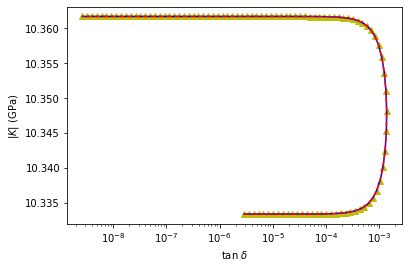

In [35]:
plt.semilogx(np.imag(K_sweep) / np.real(K_sweep),
           np.abs(K_sweep) / 1e9, 'y^')
plt.semilogx(np.imag(K_complex_SLS) / np.real(K_complex_SLS),
           np.abs(K_complex_SLS) / 1e9, 'b-')
plt.semilogx(np.imag(K_pole_zero) / np.real(K_pole_zero),
           np.abs(K_pole_zero) / 1e9, 'r--')
plt.xlabel("tan $\delta$")
plt.ylabel("$|K|$ (GPa)")

Next, we move to the shear modulus. Now, the shear viscoelasticity of the inclusion material (phase $2$) enters.

We plot the composite's stiffness in shear as $|G| / G_\mathrm{crust}$, as a function of (real) frequency. We also plot the loss tangent $\tan \delta$. Recall that $\delta \in [0, 2\pi)$ and represents the phase shift in the response relative to the forcing frequency.

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_10584\2151218868.py:23: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


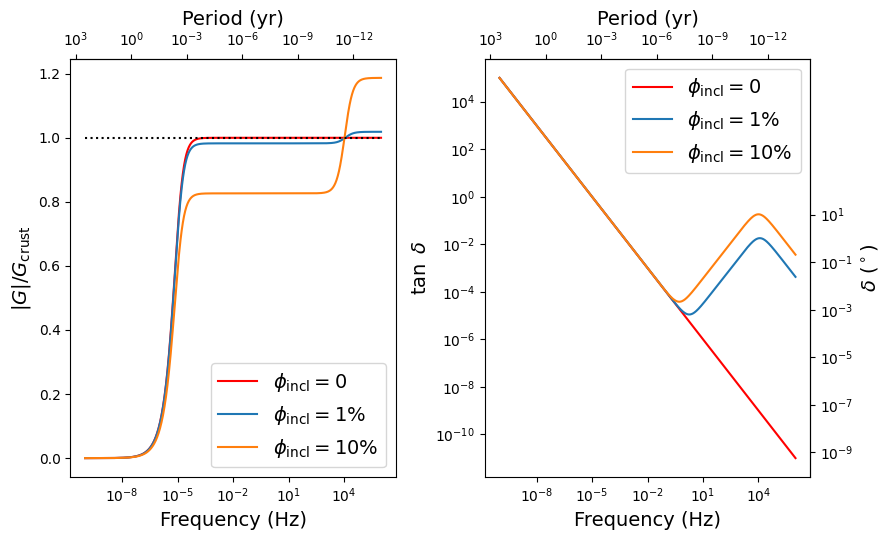

In [43]:
K1 = 10e9
K2 = 30e9
G1 = 1e9
G2 = 10e9
eta1 = 1e14
eta2 = 1e5

# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) *1j
# Compute pure 1-phase complex shear modulus (0 volume fraction phase 2)
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)

# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = \
  composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = \
  composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(9,5.5), dpi=100)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.subplot(1,2,1)
plt.semilogx(np.imag(s_vec), np.abs(G1_pure) / G1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_001) / G1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_010) / G1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|G| / G_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.subplot(1,2,2)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")


plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)


plt.gca().secondary_yaxis("right", functions=(lambda x: np.arctan(x) * 180 / (np.pi),
                                              lambda x: np.tan(np.pi*x/180))).set_ylabel('$\delta$ (${}^\circ$)', fontsize=14)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_10584\640914265.py:19: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


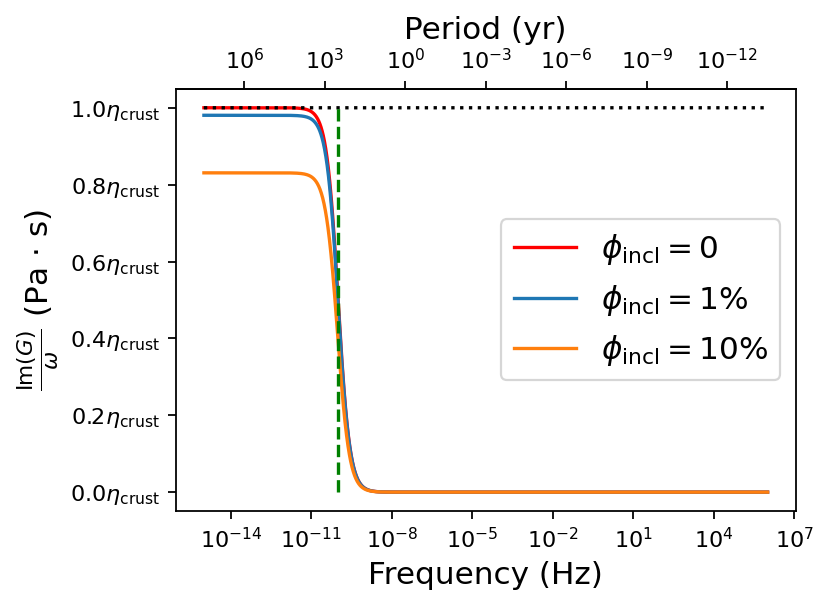

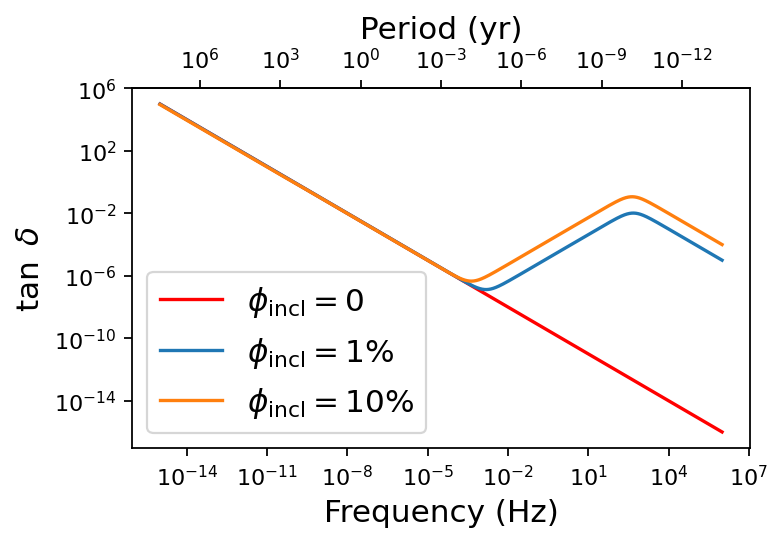

In [44]:
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta1 = 1e20
eta2 = 1e7
# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-15, 1e6, 3000) *1j
# Compute pure 1-phase complex shear modulus
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(5,3.5), dpi=160)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.semilogx(np.imag(s_vec), np.imag(G1_pure) / np.imag(s_vec) / eta1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.imag(G_s_001) / np.imag(s_vec) / eta1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.imag(G_s_010) / np.imag(s_vec) / eta1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

plt.semilogx((G1/ eta1) * np.array([1, 1]),  np.array([0, 1]), 'g--')#, label="$1$")

plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
  lambda x, pos: f"${x:.1f} \eta_\mathrm{{crust}}$"
))

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\frac{\mathrm{Im}(G)}{\omega}$ (Pa $\cdot$ s)", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.figure(figsize=(5,3.5), dpi=160)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

Text(0, 0.5, '$\\frac{\\mathrm{Im}(G)}{\\omega}$ (Pa $\\cdot$ s)')

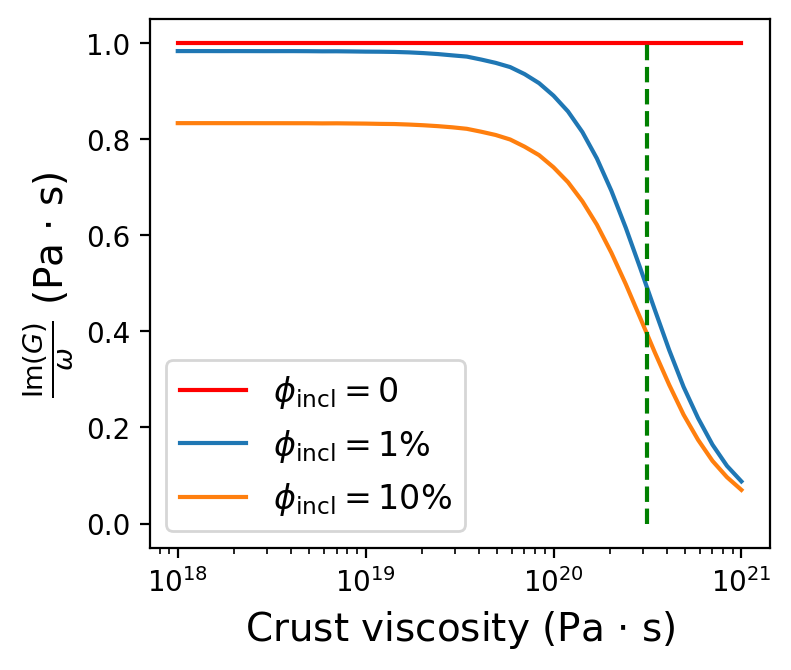

In [7]:
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta2 = 1e7

eta1_range = np.geomspace(1e18, 1e21, 40)
vec_effective_G_001 = np.full_like(eta1_range, -1.0)
vec_deltad_001 = np.full_like(eta1_range, -1.0)
vec_effective_G_010 = np.full_like(eta1_range, -1.0)
vec_deltad_010 = np.full_like(eta1_range, -1.0)

s_eps = 1 / (1000 * 3.1536e+7)
s_vec = np.array([s_eps]) *1j
# Scaling constant
scal = 1

for j, eta1 in enumerate(eta1_range):
  # Scalar value of low-frequency "limit"
  # Compute pure 1-phase complex shear modulus
  G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
  # Compute composite complex shear modulus
  roots_num, roots_den, leading_coeff = \
    composite_tools.SphericalInclusion.G_pole_zero(K1/scal, K2/scal, G1/scal, G2/scal, eta1/scal, eta2/scal, 0.01)
  G_s_001 = scal * leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
  roots_num, roots_den, leading_coeff = \
    composite_tools.SphericalInclusion.G_pole_zero(K1/scal, K2/scal, G1/scal, G2/scal, eta1/scal, eta2/scal, 0.10)
  G_s_010 = scal * leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

  vec_effective_G_001[j] = np.imag(G_s_001 / eta1 / s_eps)
  vec_deltad_001[j] = np.imag(G_s_001) / np.real(G_s_001)

  vec_effective_G_010[j] = np.imag(G_s_010 / eta1 / s_eps)
  vec_deltad_010[j] = np.imag(G_s_010) / np.real(G_s_010)

plt.figure(figsize=(4,3.5), dpi=200)
plt.semilogx(eta1_range, np.ones_like(eta1_range), 'r', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(eta1_range, vec_effective_G_001, label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(eta1_range, vec_effective_G_010, label="$\phi_\mathrm{incl} = 10\%$")

plt.semilogx((G1 / s_eps) * np.array([1, 1]),  np.array([0, 1]), 'g--')#, label="$1$")


plt.legend(fontsize=12)
plt.xlabel(f"Crust viscosity (Pa $\cdot$ s)", fontsize=14)
plt.ylabel(r"$\frac{\mathrm{Im}(G)}{\omega}$ (Pa $\cdot$ s)", fontsize=14)

# Additional examples

Additive split

For $s \neq p_i$,
$$
G(s)
=
G_\infty \frac{s (s - z_1)(s - z_2)}{(s-p_0)(s-p_1)(s-p_2)}
=
G_\infty
+ \frac{B_0}{s - p_0}
+ \frac{B_1}{s - p_1}
+ \frac{B_2}{s - p_2}
$$

In [8]:
def compute_B_coeffs(num:np.array, den:np.array) -> np.array:
  '''
  Returns vector of coefficients B_i, where

             prod_j (p_i - z_j)
   B_i = ---------------------------
          prod_{j != i} (p_i - p_j)

  are the partial fraction coefficients. A pole-zero fraction of the form

               prod_j (s - z_j)                        B_i
  G(s) = G_∞ -------------------- = G_∞ ( 1 + sum_i --------- )
               prod_j (s - p_j)                      s - p_i
  '''
  # Compute (p_i - p_j) matrix
  diff_p = (den[:,np.newaxis] - den[np.newaxis,:])
  # Overwrite diagonals (p_i - p_j) with ones
  diff_p[np.arange(den.size), np.arange(den.size)] = 1
  # Return B_i (units of frequency)
  return (den[:,np.newaxis] - num).prod(axis=1) / diff_p.prod(axis=1)

Plot util

Text(0.5, 1.0, 'Colorbar sampling curve')

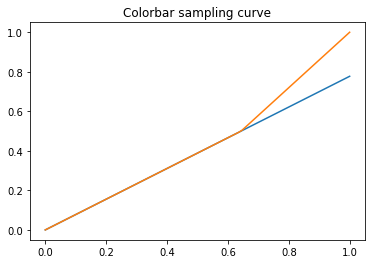

In [9]:
from matplotlib.collections import LineCollection

def varcolor_plot(x:np.array, y:np.array, c:np.array,
                  linewidth=1.0, ax=None, cmap=None, colorbar=False,
                  loglog=False):
  ''' Plot lines with variable color
   x, y, c: data with shape (data_length, n_curves).
   The last axis indexes different curves. '''
  if ax is None:
    ax = plt.gca()
  if cmap is None:
    cmap = plt.get_cmap()

  # Plot invisible curve for axis scaling
  if loglog:
    plot_handles = ax.loglog(x,y)
  else:
    plot_handles = ax.plot(x,y)
  for h in plot_handles:
    h.set_visible(False)

  if len(y.shape) == 1:
    x = x[:,np.newaxis]
    y = y[:,np.newaxis]
  elif y.size > x.size:
    if len(x.shape) == 1:
      x = x[:,np.newaxis]
    # Broadcast x to shape like y
    x = x + np.zeros_like(y)

  # Build lines for each pair of consecutive points for each curve
  line_segments = []
  for i in range(y.shape[-1]):
    # Extract (x,y) points on line
    points = np.stack((x[:,i], y[:,i],), axis=1)
    line_segments.append(np.stack((points[:-1], points[1:],), axis=1))
  # Build line collection from each pair of consecutive points
  line_collection = LineCollection(
    np.concatenate(line_segments, axis=0),
    cmap=cmap)
  # Set colorsa
  line_collection.set_array(c.T.ravel())
  line_collection.set_norm(matplotlib.colors.LogNorm(
    vmin=c.min(), vmax=c.max()))
  line_collection.set_linewidth(linewidth)
  line = ax.add_collection(line_collection)
  if colorbar:
    cbar_handle = plt.colorbar(line, ax=ax)

  return line, line_segments, c.T.ravel(), cbar_handle

''' Colormap manipulation demo '''

def recenter_diverging_cmap(x, clims):
  ''' Recenters a diverging cmap so that the color-change is at zero, given
  the color limits provided by clims.
  
  Assumes that |clims[0]| > |clims[1]|, but can be generalized for the other
  case.

  Input variable x is a sampling vector taking values in [0,1].
  '''
  # Compression factor
  cn = clims / np.abs(clims).max()
  # Factor that compresses [clims[0],0] to [0, 0.5]
  # image_factor = 0.5 * (1 + (0 - cn[0]) / (cn[1] - cn[0]))
  image_factor = 0.5 * (1 - cn[1] / cn[0])

  # Maps to a subset of [0,1] by truncating
  map_truncate = image_factor * x
  # Remap unused portion of colormap to increase richness in truncated part
  # breakpoint = 1 / (1 - (cn[1] / cn[0]))
  breakpoint = 0.5 / image_factor
  # map_rescaled = (image_factor * x
  #   + ((1 - image_factor * breakpoint) / (1 - breakpoint) - image_factor)
  #     * (x - breakpoint) * (x >= breakpoint).astype(float))
  map_rescaled = image_factor * x + (0.5 * (1 - cn[0] / cn[1]) - image_factor) \
      * (x - breakpoint) * (x >= breakpoint).astype(float)

  return map_truncate, map_rescaled

def high_constrast_div_map(t):
  # Truncate positive color map (value between 0 and 1)
  pos_color_truncation = 0.7
  pos_data_colors = matplotlib.cm.gist_heat(pos_color_truncation * (2 * t - 1))
  neg_color_truncation = 1.0
  neg_data_colors = matplotlib.cm.bone_r(neg_color_truncation * (2 * t))
  # Alpha manipulation
  neg_data_colors[:,-1] = 1 # neg_data_colors[:,0]

  cdata = (pos_data_colors * (t > 0.5).astype(float)[:,np.newaxis]
           + neg_data_colors * (t <= 0.5).astype(float)[:,np.newaxis])
  return cdata

color_test_x = np.linspace(0, 1, 100)
map_truncate, map_rescaled = recenter_diverging_cmap(color_test_x,
  np.array([-8.        ,  4.43478366]))
plt.plot(color_test_x, map_truncate)
plt.plot(color_test_x, map_rescaled)
plt.title("Colorbar sampling curve")

In [10]:
big_num = 1e100
K1_example = 1e10
K2_example = 1e10
G1_example = 1e10
G2_example = 10 * G1_example
eta1_example = 1e15
eta2_example = 1e5

num, den, prefactor = \
  composite_tools.SphericalInclusion.G_pole_zero(K1_example, K2_example,
                                                 G1_example, big_num,
                                                 eta1_example,
                                                 eta2_example, 0.1)

eta2_range = np.geomspace(1e5, 1e17, 1000)
num_range = np.zeros((len(eta2_range), 3))
den_range = np.zeros((len(eta2_range), 3))
B_i_range = np.zeros((len(eta2_range), 3))
prefactor = np.zeros_like(eta2_range)


for i, eta2 in enumerate(eta2_range):
  num_range[i], den_range[i], prefactor[i] = \
    composite_tools.SphericalInclusion.G_pole_zero(K1_example, K2_example,
                                                   G1_example, G2_example,
                                                   eta1_example, eta2, 0.1)
  B_i_range[i] = compute_B_coeffs(num_range[i], den_range[i])


(3.4909046786490853e-06, 1015506.9693763908)

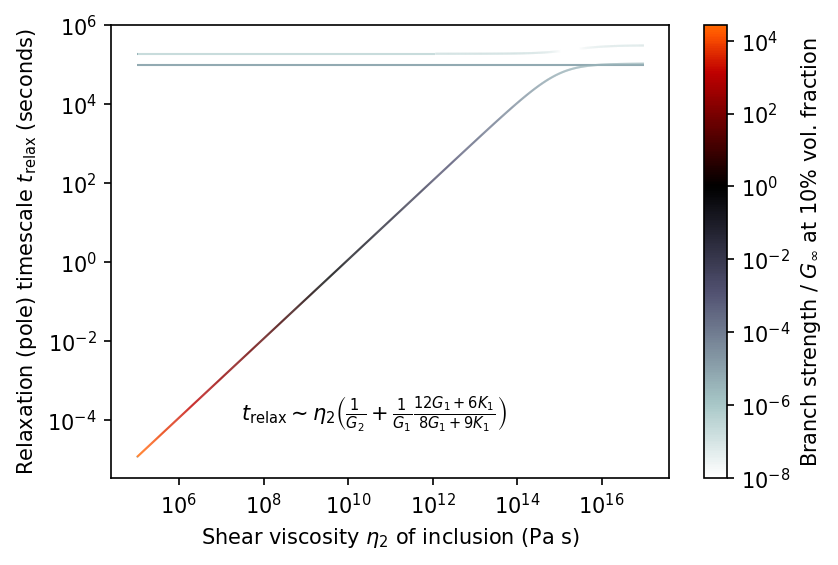

In [11]:
fig, ax = plt.subplots(dpi=150)

# Abs value of B_i / G_infty
B_abs = np.abs(B_i_range)
# Normalization
B_abs_normalized = np.abs(B_i_range) / np.abs(B_i_range).max(axis=1, keepdims=True)
# Pick color data
cdata = np.clip(B_abs[:,:], 1e-8, None)
cdata_log = np.log10(cdata)

# RGBA sample points
clims = np.array((cdata_log.min(), cdata_log.max(),))
trunc_min = 0.0
trunc_max = 0.5 * (1 + (clims[1] - 0) / (0 - (clims[0])))
# Re-centered diverging colormap sampling values (0, 1)
map_truncate, map_rescaled = recenter_diverging_cmap(
  np.linspace(0, 1, 100), clims)

high_contrast_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
  f'high_contrast_cmap',
  high_constrast_div_map(np.linspace(0, 1, 100)))

use_builtin = False
if use_builtin:
  color_dat = matplotlib.cm.RdGy_r(map_rescaled)
  color_dat[:,0:3] = 1 - color_dat[:,0:3]
else:
  color_dat = high_contrast_cmap(map_rescaled)

rescaled_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
  f'rescaled_cmap',
  color_dat)

lc, dat, colordat, cbar_handle = varcolor_plot(eta2_range,
              -1/den_range[:,:],
              cdata,
              ax=ax, cmap=rescaled_cmap, colorbar=True, loglog=True)

plt.xlabel(r"Shear viscosity $\eta_2$ of inclusion (Pa s)")
plt.ylabel(r"Relaxation (pole) timescale $t_\mathrm{relax}$ (seconds)")

asymptotic_slope = 1 / G2_example + (12*G1_example + 6*K1_example) / (G1_example*(8*G1_example + 9*K1_example))
# plt.plot(eta2_range, asymptotic_slope*eta2_range, 'k:', linewidth=1)

_xlim, _ylim = plt.xlim(), plt.ylim()
# Slope triangle
tri_coordinates = np.array([
  [3e7, 1e-4,],
  [8e9, 1e-4,],
  [8e9, 0.0,],
])

# Unused: plot slope triangle
# tri_coordinates[2,1] = tri_coordinates[2,0] / tri_coordinates[0,0] * tri_coordinates[0,1]
# plt.loglog(tri_coordinates[0:2,0], tri_coordinates[0:2,1], 'k', linewidth=0.75)
# plt.loglog(tri_coordinates[1:3,0], tri_coordinates[1:3,1], 'k', linewidth=0.75)
# plt.loglog(tri_coordinates[[0,2],0], tri_coordinates[[0,2],1], 'k', linewidth=0.75)

plt.annotate(r"$t_\mathrm{relax} \sim \eta_2 \left( \frac{1}{G_2} + \frac{1}{G_1} \frac{12G_1 + 6 K_1}{8G_1 + 9K_1} \right)$",
             tri_coordinates[1,:], tri_coordinates[0,:],)

# cbar_handle.ticks = matplotlib.LogFormatter(10, labelOnlyBase=False) 
# cb = plt.colorbar(ticks=[1,5,10,20,50], format=formatter)
# cbar_handle.formatter = matplotlib.ticker.LogFormatterExponent
cbar_handle.set_label("Branch strength / $G_\infty$ at 10% vol. fraction")

plt.xlim(_xlim)
plt.ylim(_ylim)

To compare to Maxwell viscoelastic:
$$
G_\mathrm{MV}(s) = \frac{Gs}{s + G/\eta} = G \left( 1 - \frac{G/\eta}{s + G/\eta} \right).
$$
To recover single-phase behaviour as $\eta_2 \geq \eta_1$, we look for a sum of branch strengths on the order of $-G/\eta$.